# Global Solution 2026 — AI for RPA
## Análise Automatizada de Missões Espaciais

**Disciplina:** AI for RPA  
**Curso:** Graduação em Tecnologia — 1º Semestre  
**Instituição:** FIAP  

---

### O que esse projeto faz

A ideia é simular um sistema automatizado que analisa dados de missões espaciais. O sistema lê logs de texto das missões e também imagens captadas pelos sensores das naves, processa tudo isso de forma automática e gera um relatório Excel no final.

Dividimos o projeto em duas partes principais:

1. **NLP (Processamento de Linguagem Natural):** lê os arquivos de log e identifica eventos críticos, alertas e palavras importantes
2. **Visão Computacional:** analisa as imagens dos sensores para detectar anomalias

No final tudo vai para um Excel gerado automaticamente pelo código.


Arthur Baptista dos Santos RM - 565346
Joao Pedro RM - 561738
Nelson Felix RM - 565603

---
## Célula 1 — Instalando as bibliotecas necessárias

Primeiro precisamos instalar as libs que vamos usar. O `-q` é só pra não poluir a saída com um monte de texto de instalação.

In [1]:
!pip install nltk opencv-python-headless openpyxl pandas Pillow numpy matplotlib -q
print("Bibliotecas instaladas com sucesso!")

Bibliotecas instaladas com sucesso!


---
## Célula 2 — Importações e configuração inicial

Aqui importamos tudo que vamos precisar e já baixamos os recursos do NLTK (tokenizador e stopwords em português).

In [2]:
import os
import re
import glob
import datetime
import numpy as np
import pandas as pd
import cv2
import openpyxl
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image, ImageDraw
from openpyxl.styles import PatternFill, Font, Alignment
from openpyxl.utils import get_column_letter
import nltk

# baixando os recursos do NLTK que precisamos
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# criando as pastas que vamos usar (se já existirem não dá erro por causa do exist_ok)
os.makedirs('data/logs', exist_ok=True)
os.makedirs('data/images', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

print("Tudo importado e pastas criadas!")

Tudo importado e pastas criadas!


---
## Célula 3 — Criando os dados de teste

Como não temos dados reais de missões espaciais, criamos dados simulados pra testar o sistema. São 3 logs de missão em formato de texto e 6 imagens de sensor geradas com numpy.

Os logs seguem um formato padrão com cabeçalho (MISSAO, DATA, etc.) e eventos com horário no formato `[HH:MM]`.

In [3]:
# conteúdo dos logs de missão
LOGS = {
    'data/logs/missao_artemis_01.txt': """MISSAO: ARTEMIS-01
DATA: 2026-03-15 08:00 UTC
TRIPULACAO: 4 astronautas

[08:00] Sistema de propulsao inicializado. Todos os parametros normais.
[08:45] Decolagem realizada com sucesso. Velocidade de escape atingida.
[09:30] Separacao do primeiro estagio confirmada. Trajetoria estavel.
[10:15] Comunicacao com estacao terra estabelecida. Sinal forte.
[11:00] ALERTA: Temperatura do reator 1 acima do limite: 340C (limite: 320C). Acionando resfriamento auxiliar.
[11:05] Sistema de resfriamento auxiliar ativado. Temperatura reduzindo.
[11:20] Temperatura normalizada: 315C. Situacao sob controle.
[12:00] Manobra de insercao orbital executada. Orbita circular confirmada.
[13:00] CRITICO: Falha no painel solar secundario. Potencia reduzida em 30%.
[13:10] Sistemas nao essenciais desligados para preservar energia.
[13:45] Reparos iniciados pela equipe de manutencao a bordo.
[14:30] Painel solar parcialmente restaurado. Potencia em 85%.
[15:00] Todos os sistemas operacionais. Missao continua conforme planejado.
[16:00] Coleta de amostras do solo lunar iniciada via braco robotico.
[17:00] 12 amostras coletadas com sucesso. Analise preliminar em andamento.
[18:00] AVISO: Nivel de oxigenio na cabine: 19.2% (minimo recomendado: 19.5%).
[18:15] Sistema de reciclagem de ar ajustado. Nivel de oxigenio subindo.
[18:30] Nivel de oxigenio: 20.1%. Situacao normalizada.
[20:00] Encerramento das atividades do dia. Tripulacao em repouso.
""",
    'data/logs/missao_artemis_02.txt': """MISSAO: ARTEMIS-02
DATA: 2026-04-10 06:00 UTC
TRIPULACAO: 3 astronautas

[06:00] Pre-launch checklist completo. Todos os sistemas verificados.
[06:30] Decolagem nominal. Sem anomalias detectadas.
[07:00] Separacao do primeiro estagio OK. Segundo estagio ignicionado.
[07:45] Insercao na orbita de transferencia lunar. Trajetoria confirmada.
[09:00] CRITICO: Falha no sistema de navegacao principal. Mudando para backup.
[09:05] Sistema de navegacao backup ativado. Trajetoria recalculada.
[09:15] Trajetoria corrigida com sucesso. Missao continua.
[10:00] ALERTA: Micrometeoritos detectados na trajetoria. Manobra evasiva iniciada.
[10:10] Manobra evasiva concluida. Sem impactos registrados.
[12:00] Ponto medio da trajetoria atingido. Comunicacao com FIAP Ground Control estavel.
[14:00] CRITICO: Vazamento de combustivel no tanque 2. Taxa: 0.3L/min.
[14:10] Valvula de isolamento ativada. Vazamento contido.
[14:20] Estimativa de combustivel restante: suficiente para completar missao.
[16:00] Insercao na orbita lunar realizada. Altitude: 100km.
[17:00] Experimentos cientificos iniciados. Coleta de dados geofisicos.
[18:00] Detectado campo magnetico anomalo na regiao do polo sul lunar.
[19:00] CRITICO: Tempestade solar detectada. Aumentando blindagem de radiacao.
[19:30] Tripulacao em area protegida. Dose de radiacao dentro dos limites.
[21:00] Tempestade solar dissipando. Retorno as atividades normais.
[22:00] Dia de missao encerrado. Todos os sistemas operacionais.
""",
    'data/logs/missao_europa_03.txt': """MISSAO: EUROPA-EXPLORER-03
DATA: 2026-05-20 12:00 UTC
OBJETIVO: Analise da superficie e oceano subterraneo de Europa (lua de Jupiter)

[12:00] Sonda ativada remotamente. Todos os subsistemas online.
[12:30] Comunicacao estabelecida com delay de 43 minutos (distancia Jupiter).
[13:00] Sensor de espectroscopia calibrado. Pronto para coleta de dados.
[14:00] Primeiras imagens da superficie de Europa capturadas.
[14:30] Detectadas rachaduras na crosta de gelo. Possiveis plumas de agua.
[15:00] ALERTA: Radiacao de Jupiter acima do normal: 850 rad/h (limite: 800 rad/h).
[15:10] Modo de operacao reduzida ativado para proteger eletronica.
[16:00] Analise espectroscopica detectou presenca de compostos organicos.
[16:30] CRITICO: Falha no aquecedor do compartimento de baterias. Temperatura: -140C.
[16:35] Bateria auxiliar de emergencia ativada. Sistema estabilizado.
[17:00] Perfurador de gelo iniciado. Profundidade alvo: 2 metros.
[18:00] Perfuracao concluida. Amostras de gelo coletadas.
[18:30] Analise das amostras: presenca de sal e compostos de enxofre detectados.
[19:00] CRITICO: Comunicacao com Terra intermitente. Interferencia solar.
[19:30] Comunicacao reestabelecida via antena de backup.
[20:00] Dados transmitidos com sucesso para FIAP Mission Control.
[21:00] Missao do dia concluida com sucesso. Descobertas significativas registradas.
"""
}

# salvando os logs em arquivo
for caminho, conteudo in LOGS.items():
    with open(caminho, 'w', encoding='utf-8') as f:
        f.write(conteudo)
    print(f'  criado: {caminho}')

# agora geramos as imagens simuladas de sensor
# usamos numpy pra criar arrays de pixels e PIL pra salvar como PNG
rng = np.random.default_rng(42)  # seed fixa pra sempre gerar as mesmas imagens

def criar_imagem_superficie(nome, anomalia=False):
    # superficie lunar tem pixels escuros (valores 30-80)
    arr = rng.integers(30, 80, (256, 256), dtype=np.uint8)
    if anomalia:
        # quando tem anomalia, uma região fica com brilho muito alto
        arr[100:150, 100:150] = rng.integers(200, 255, (50, 50), dtype=np.uint8)
    img = Image.fromarray(arr, mode='L').convert('RGB')
    ImageDraw.Draw(img).text((5, 5), 'ANOMALIA' if anomalia else 'NORMAL', fill=(255, 255, 0))
    img.save(f'data/images/{nome}')

def criar_imagem_pluma(nome):
    # pluma de vapor: ponto brilhante no centro da imagem
    arr = rng.integers(10, 40, (256, 256), dtype=np.uint8)
    cx, cy = 128, 128
    Y, X = np.ogrid[:256, :256]
    dist = np.sqrt((X - cx)**2 + (Y - cy)**2)
    mask = dist < 40
    arr[mask] = np.clip(arr[mask].astype(int) + ((40 - dist[mask]) * 4).astype(int), 0, 255).astype(np.uint8)
    img = Image.fromarray(arr, mode='L').convert('RGB')
    ImageDraw.Draw(img).text((5, 5), 'PLUMA', fill=(0, 255, 255))
    img.save(f'data/images/{nome}')

def criar_imagem_cratera(nome):
    # cratera: anel escuro no meio da imagem
    arr = rng.integers(50, 100, (256, 256), dtype=np.uint8)
    cx, cy = 128, 128
    Y, X = np.ogrid[:256, :256]
    dist_anel = np.abs(np.sqrt((X - cx)**2 + (Y - cy)**2) - 60)
    mask = dist_anel < 10
    arr[mask] = np.clip(arr[mask].astype(int) - ((10 - dist_anel[mask]) * 8).astype(int), 0, 255).astype(np.uint8)
    img = Image.fromarray(arr, mode='L').convert('RGB')
    ImageDraw.Draw(img).text((5, 5), 'CRATERA', fill=(255, 128, 0))
    img.save(f'data/images/{nome}')

criar_imagem_superficie('artemis01_sensor_001.png', anomalia=False)
criar_imagem_superficie('artemis01_sensor_002.png', anomalia=True)
criar_imagem_superficie('artemis02_sensor_001.png', anomalia=False)
criar_imagem_pluma('europa03_sensor_001.png')
criar_imagem_cratera('artemis02_sensor_002.png')
criar_imagem_superficie('europa03_sensor_002.png', anomalia=True)

print(f'\nDados criados!')
print(f'  {len(LOGS)} logs em data/logs/')
print(f'  6 imagens em data/images/')

  criado: data/logs/missao_artemis_01.txt
  criado: data/logs/missao_artemis_02.txt
  criado: data/logs/missao_europa_03.txt


/tmp/ipykernel_9280/3489522862.py:92: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L').convert('RGB')



Dados criados!
  3 logs em data/logs/
  6 imagens em data/images/


/tmp/ipykernel_9280/3489522862.py:104: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L').convert('RGB')
/tmp/ipykernel_9280/3489522862.py:116: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode='L').convert('RGB')


---
## Célula 4 — Módulo NLP

Aqui implementamos o processamento de linguagem natural. A ideia é ler cada linha do log e classificar o evento como CRITICO, ALERTA, NORMAL ou INFO, dependendo das palavras que aparecem no texto.

Também usamos o NLTK pra tokenizar o texto todo e extrair as palavras mais frequentes (tirando stopwords como "de", "que", "para" etc.).

In [4]:
# stopwords em português e inglês (palavras que não agregam significado)
STOPWORDS_PT = set(stopwords.words('portuguese')) | set(stopwords.words('english'))

# palavras que indicam cada nível de severidade
PALAVRAS_CRITICO = {'critico', 'falha', 'vazamento', 'falhou', 'critica', 'emergencia'}
PALAVRAS_ALERTA  = {'alerta', 'anomalo', 'acima', 'intermitente', 'anomalia', 'aviso'}
PALAVRAS_OK      = {'normalizado', 'normal', 'sucesso', 'confirmada', 'estavel', 'restaurado'}

# regex pra capturar as linhas de evento no formato [HH:MM] ...
REGEX_EVENTO = re.compile(r'\[(\d{2}:\d{2})\]\s*(CRITICO|ALERTA|AVISO)?:?\s*(.*)', re.IGNORECASE)


def classificar_linha(texto):
    """verifica quais palavras-chave aparecem na linha e retorna a severidade"""
    t = texto.lower()
    if any(p in t for p in PALAVRAS_CRITICO):
        return 'CRITICO'
    if any(p in t for p in PALAVRAS_ALERTA):
        return 'ALERTA'
    if any(p in t for p in PALAVRAS_OK):
        return 'NORMAL'
    return 'INFO'


def extrair_palavras_chave(texto, top_n=10):
    """tokeniza o texto e retorna as palavras mais frequentes (sem stopwords)"""
    tokens = word_tokenize(texto.lower(), language='portuguese')
    # filtra: só palavras, sem stopwords, com mais de 3 letras
    tokens = [t for t in tokens if t.isalpha() and t not in STOPWORDS_PT and len(t) > 3]
    return [p for p, _ in Counter(tokens).most_common(top_n)]


def analisar_log(caminho):
    """lê um arquivo de log e extrai todas as informações relevantes"""
    with open(caminho, encoding='utf-8') as f:
        linhas = f.readlines()

    cabecalho = {}   # armazena MISSAO, DATA, TRIPULACAO etc.
    eventos = []     # lista de eventos encontrados
    texto_completo = ''

    for linha in linhas:
        linha = linha.strip()
        if not linha:
            continue

        # linhas de cabeçalho são em maiúsculo antes dos dois pontos
        if ':' in linha and not linha.startswith('['):
            chave, _, valor = linha.partition(':')
            if chave.isupper():
                cabecalho[chave.strip()] = valor.strip()
                continue

        texto_completo += ' ' + linha

        # tenta encontrar o padrão de evento [HH:MM]
        m = REGEX_EVENTO.match(linha)
        if m:
            hora, _, descricao = m.groups()
            eventos.append({
                'hora': hora,
                'severidade': classificar_linha(linha),
                'descricao': descricao.strip()
            })

    criticos = [e for e in eventos if e['severidade'] == 'CRITICO']
    alertas  = [e for e in eventos if e['severidade'] == 'ALERTA']

    # define o status geral da missão pelo pior evento
    if criticos:
        status = 'CRITICO'
    elif alertas:
        status = 'ALERTA'
    else:
        status = 'NORMAL'

    return {
        'missao':            cabecalho.get('MISSAO', 'Desconhecida'),
        'data':              cabecalho.get('DATA', ''),
        'tripulacao':        cabecalho.get('TRIPULACAO', ''),
        'total_eventos':     len(eventos),
        'criticos':          len(criticos),
        'alertas':           len(alertas),
        'status_geral':      status,
        'palavras_chave':    extrair_palavras_chave(texto_completo),
        'eventos':           eventos,
        'detalhes_criticos': [e['descricao'] for e in criticos],
        'arquivo':           os.path.basename(caminho),
    }


print('Módulo NLP pronto!')

Módulo NLP pronto!


---
## Célula 5 — Módulo de Visão Computacional

Aqui usamos o OpenCV pra analisar as imagens dos sensores. A lógica é simples:

- Calculamos o brilho médio da imagem (média dos pixels em escala de cinza)
- Aplicamos um limiar pra detectar regiões com brilho muito alto (possível anomalia térmica)
- Baseado nisso, classificamos a imagem em categorias

In [5]:
def analisar_imagem(caminho):
    # carrega a imagem com OpenCV
    img = cv2.imread(caminho)
    if img is None:
        raise FileNotFoundError(f'Imagem não encontrada: {caminho}')

    # converte pra escala de cinza pra facilitar os cálculos
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    media  = float(np.mean(gray))
    desvio = float(np.std(gray))
    total  = gray.size

    # limiar de 180: pixels acima disso são considerados "muito brilhantes"
    _, mask = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)
    contornos, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    pct_anomala = round(float(np.sum(mask > 0)) / total * 100, 2)

    # se mais de 2% dos pixels estão acima do limiar, consideramos anomalia
    anomalia = pct_anomala > 2.0

    # classifica a imagem com base nas métricas calculadas
    if anomalia and media > 120:
        classificacao = 'ANOMALIA TERMICA'
    elif anomalia:
        classificacao = 'ANOMALIA DETECTADA'
    elif desvio > 60:
        classificacao = 'ALTO CONTRASTE (cratera/pluma)'
    elif media < 50:
        classificacao = 'SUPERFICIE ESCURA (normal)'
    else:
        classificacao = 'SUPERFICIE NORMAL'

    # histograma simplificado em 3 faixas
    escuros    = round(np.sum(gray < 85) / total * 100, 1)
    medios     = round(np.sum((gray >= 85) & (gray < 170)) / total * 100, 1)
    brilhantes = round(np.sum(gray >= 170) / total * 100, 1)

    return {
        'arquivo':              os.path.basename(caminho),
        'resolucao':            f"{img.shape[1]}x{img.shape[0]}",
        'brilho_medio':         round(media, 2),
        'desvio_padrao':        round(desvio, 2),
        'contraste':            round(desvio, 2),
        'regioes_anomalas':     len(contornos),
        'percentual_anomalo':   pct_anomala,
        'anomalia_detectada':   anomalia,
        'classificacao':        classificacao,
        'pixels_escuros_pct':   escuros,
        'pixels_medios_pct':    medios,
        'pixels_brilhantes_pct': brilhantes,
    }


print('Módulo de Visão Computacional pronto!')

Módulo de Visão Computacional pronto!


---
## Célula 6 — Executando o pipeline

Agora rodamos os dois módulos em sequência: primeiro o NLP nos logs, depois a visão computacional nas imagens.

In [6]:
print('=' * 50)
print('  FIAP GS 2026 — Análise de Missões Espaciais')
print('=' * 50)

# etapa 1: processar os logs com NLP
print('\n[1/2] Processando logs com NLP...')
dados_nlp = []
for arq in sorted(glob.glob('data/logs/*.txt')):
    resultado = analisar_log(arq)
    dados_nlp.append(resultado)
    print(f'  {resultado["missao"]:<25} | Status: {resultado["status_geral"]:<8} '
          f'| Críticos: {resultado["criticos"]} | Alertas: {resultado["alertas"]}')

# etapa 2: analisar as imagens
print('\n[2/2] Analisando imagens com Visão Computacional...')
dados_visao = []
for arq in sorted(glob.glob('data/images/*.png') + glob.glob('data/images/*.jpg')):
    try:
        r = analisar_imagem(arq)
        dados_visao.append(r)
        status_img = 'ANOMALIA DETECTADA' if r['anomalia_detectada'] else 'normal'
        print(f'  {r["arquivo"]:<35} | {r["classificacao"]:<30} | {status_img}')
    except Exception as e:
        print(f'  ERRO em {arq}: {e}')

print(f'\nProcessamento concluído!')
print(f'  Logs analisados  : {len(dados_nlp)}')
print(f'  Imagens analisadas: {len(dados_visao)}')

  FIAP GS 2026 — Análise de Missões Espaciais

[1/2] Processando logs com NLP...
  ARTEMIS-01                | Status: CRITICO  | Críticos: 1 | Alertas: 2
  ARTEMIS-02                | Status: CRITICO  | Críticos: 4 | Alertas: 3
  EUROPA-EXPLORER-03        | Status: CRITICO  | Críticos: 3 | Alertas: 1

[2/2] Analisando imagens com Visão Computacional...
  artemis01_sensor_001.png            | SUPERFICIE NORMAL              | normal
  artemis01_sensor_002.png            | ANOMALIA DETECTADA             | ANOMALIA DETECTADA
  artemis02_sensor_001.png            | SUPERFICIE NORMAL              | normal
  artemis02_sensor_002.png            | SUPERFICIE NORMAL              | normal
  europa03_sensor_001.png             | SUPERFICIE ESCURA (normal)     | normal
  europa03_sensor_002.png             | ANOMALIA DETECTADA             | ANOMALIA DETECTADA

Processamento concluído!
  Logs analisados  : 3
  Imagens analisadas: 6


---
## Célula 7 — Visualizando os resultados do NLP

Aqui mostramos os dados em forma de tabela e geramos dois gráficos: um de barras com os eventos por missão e um de pizza com a distribuição de status.

Resumo NLP por missão:


,Missão,Status,Total Eventos,Críticos,Alertas,Palavras-chave
0,ARTEMIS-01,CRITICO,19,1,2,"sistema, temperatura, nivel, oxigenio, todos"
1,ARTEMIS-02,CRITICO,20,4,3,"trajetoria, lunar, critico, missao, todos"
2,EUROPA-EXPLORER-03,CRITICO,17,3,1,"comunicacao, gelo, ativada, jupiter, dados"


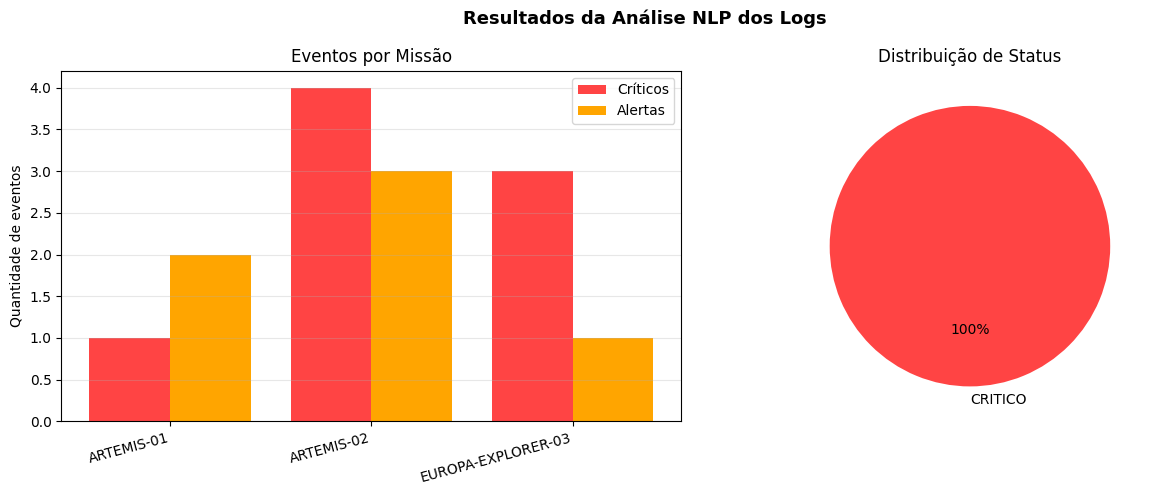

Gráfico salvo em outputs/grafico_nlp.png


In [7]:
# monta um DataFrame com o resumo de cada missão
df_nlp = pd.DataFrame([{
    'Missão':        d['missao'],
    'Status':        d['status_geral'],
    'Total Eventos': d['total_eventos'],
    'Críticos':      d['criticos'],
    'Alertas':       d['alertas'],
    'Palavras-chave': ', '.join(d['palavras_chave'][:5]),
} for d in dados_nlp])

print('Resumo NLP por missão:')
display(df_nlp)

# gráfico com dois subplots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Resultados da Análise NLP dos Logs', fontsize=13, fontweight='bold')

missoes  = [d['missao']   for d in dados_nlp]
criticos = [d['criticos'] for d in dados_nlp]
alertas  = [d['alertas']  for d in dados_nlp]
x = range(len(missoes))

# barras agrupadas: críticos vs alertas por missão
axes[0].bar([i - 0.2 for i in x], criticos, 0.4, label='Críticos', color='#FF4444')
axes[0].bar([i + 0.2 for i in x], alertas,  0.4, label='Alertas',  color='#FFA500')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(missoes, rotation=15, ha='right')
axes[0].set_title('Eventos por Missão')
axes[0].set_ylabel('Quantidade de eventos')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# pizza com distribuição dos status
status_count = Counter(d['status_geral'] for d in dados_nlp)
cores  = {'CRITICO': '#FF4444', 'ALERTA': '#FFA500', 'NORMAL': '#44BB44'}
labels = list(status_count.keys())
values = list(status_count.values())
axes[1].pie(values, labels=labels,
            colors=[cores.get(l, '#888') for l in labels],
            autopct='%1.0f%%', startangle=90)
axes[1].set_title('Distribuição de Status')

plt.tight_layout()
plt.savefig('outputs/grafico_nlp.png', dpi=120, bbox_inches='tight')
plt.show()
print('Gráfico salvo em outputs/grafico_nlp.png')

---
## Célula 8 — Visualizando os resultados da Visão Computacional

Mostramos a tabela com as métricas de cada imagem e exibimos as imagens em grade, com o título em vermelho quando detectou anomalia.

Resumo das imagens analisadas:


,Arquivo,Classificação,Brilho Médio,Contraste,% Anômala,Anomalia?
0,artemis01_sensor_001.png,SUPERFICIE NORMAL,54.67,15.73,0.14,NÃO
1,artemis01_sensor_002.png,ANOMALIA DETECTADA,61.48,36.72,3.98,SIM
2,artemis02_sensor_001.png,SUPERFICIE NORMAL,54.79,15.74,0.14,NÃO
3,artemis02_sensor_002.png,SUPERFICIE NORMAL,70.22,20.38,0.00,NÃO
4,europa03_sensor_001.png,SUPERFICIE ESCURA (normal),28.78,20.10,0.03,NÃO
5,europa03_sensor_002.png,ANOMALIA DETECTADA,61.35,36.67,3.97,SIM


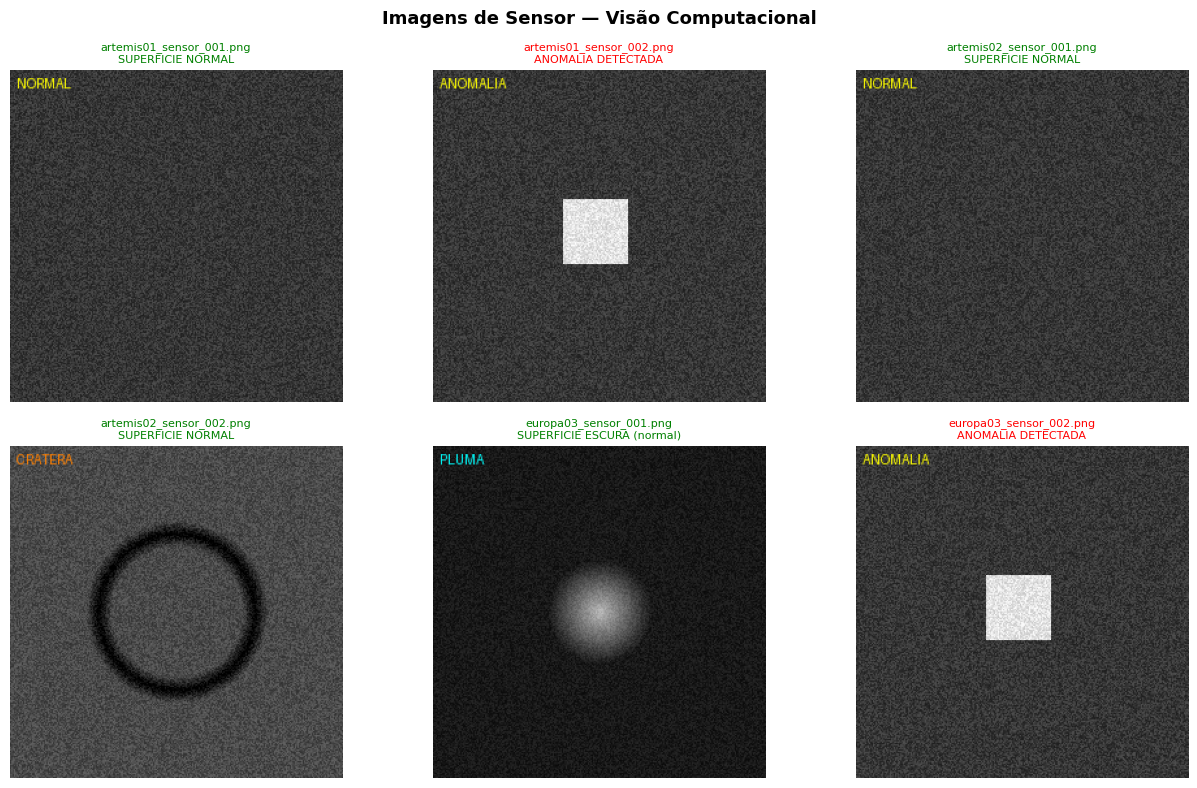

Gráfico salvo em outputs/grafico_visao.png


In [8]:
# tabela resumo das imagens
df_visao = pd.DataFrame([{
    'Arquivo':       d['arquivo'],
    'Classificação': d['classificacao'],
    'Brilho Médio':  d['brilho_medio'],
    'Contraste':     d['contraste'],
    '% Anômala':     d['percentual_anomalo'],
    'Anomalia?':     'SIM' if d['anomalia_detectada'] else 'NÃO',
} for d in dados_visao])

print('Resumo das imagens analisadas:')
display(df_visao)

# mostra as imagens em grade 2x3
arquivos_img = sorted(glob.glob('data/images/*.png'))
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
fig.suptitle('Imagens de Sensor — Visão Computacional', fontsize=13, fontweight='bold')

for i, (arq, ax) in enumerate(zip(arquivos_img, axes.flat)):
    img = cv2.imread(arq)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV lê em BGR, matplotlib exibe em RGB
    resultado = dados_visao[i]
    cor = 'red' if resultado['anomalia_detectada'] else 'green'
    ax.imshow(img_rgb)
    ax.set_title(f"{resultado['arquivo']}\n{resultado['classificacao']}",
                 color=cor, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/grafico_visao.png', dpi=120, bbox_inches='tight')
plt.show()
print('Gráfico salvo em outputs/grafico_visao.png')

---
## Célula 9 — Gerando o relatório Excel

Essa é a etapa final do pipeline. O código gera um arquivo Excel com **5 abas** de forma automática:

- **Resumo Executivo:** visão geral de todas as missões
- **Análise NLP - Logs:** todos os eventos com horário e severidade
- **Palavras-chave:** as palavras mais frequentes por missão
- **Visão Computacional:** resultados da análise de cada imagem
- **Eventos Críticos:** lista separada só com os eventos críticos

As células ficam coloridas de acordo com a severidade (vermelho = crítico, laranja = alerta, verde = normal).

In [9]:
ARQUIVO_EXCEL = 'outputs/relatorio_missoes.xlsx'

# cores em hex pra usar nas células do Excel
COR_CRITICO = 'FF4444'
COR_ALERTA  = 'FFA500'
COR_NORMAL  = '44BB44'
COR_INFO    = '4488FF'
COR_HEADER  = '1A237E'
COR_TITULO  = '0D47A1'


def cor_status(s):
    mapa = {'CRITICO': COR_CRITICO, 'ALERTA': COR_ALERTA, 'NORMAL': COR_NORMAL, 'INFO': COR_INFO}
    return mapa.get(s.upper(), 'FFFFFF')


def aplicar_cabecalho(ws, linha, colunas, cor=COR_HEADER):
    """aplica formatação de cabeçalho em uma linha da planilha"""
    fill = PatternFill('solid', fgColor=cor)
    font = Font(color='FFFFFF', bold=True)
    for c, v in enumerate(colunas, 1):
        cell = ws.cell(row=linha, column=c, value=v)
        cell.fill = fill
        cell.font = font
        cell.alignment = Alignment(horizontal='center', vertical='center')


def ajustar_largura(ws):
    """ajusta a largura de cada coluna com base no conteúdo"""
    for col in ws.columns:
        L = get_column_letter(col[0].column)
        w = max((len(str(c.value)) for c in col if c.value), default=8)
        ws.column_dimensions[L].width = min(w + 4, 60)


wb = openpyxl.Workbook()

# ── Aba 1: Resumo Executivo ────────────────────────────────────────────────
ws = wb.active
ws.title = 'Resumo Executivo'

ws.merge_cells('A1:F1')
t = ws['A1']
t.value = 'SISTEMA DE ANÁLISE DE MISSÕES ESPACIAIS — FIAP GS 2026'
t.font  = Font(color='FFFFFF', bold=True, size=13)
t.fill  = PatternFill('solid', fgColor=COR_TITULO)
t.alignment = Alignment(horizontal='center', vertical='center')
ws.row_dimensions[1].height = 28

# informações gerais
resumo = [
    ('Data de Geração:',           datetime.datetime.now().strftime('%d/%m/%Y %H:%M:%S')),
    ('Missões Analisadas:',        len(dados_nlp)),
    ('Total de Eventos Críticos:', sum(d['criticos'] for d in dados_nlp)),
    ('Total de Alertas:',          sum(d['alertas']  for d in dados_nlp)),
    ('Imagens Analisadas:',        len(dados_visao)),
    ('Imagens com Anomalia:',      sum(1 for d in dados_visao if d['anomalia_detectada'])),
]
for i, (label, valor) in enumerate(resumo, 3):
    ws.cell(row=i, column=1, value=label).font = Font(bold=True)
    ws.cell(row=i, column=2, value=valor)

# tabela de missões
aplicar_cabecalho(ws, 10, ['Missão', 'Data', 'Status', 'Críticos', 'Alertas', 'Top Keywords'])
for i, d in enumerate(dados_nlp, 11):
    ws.cell(row=i, column=1, value=d['missao'])
    ws.cell(row=i, column=2, value=d['data'])
    c = ws.cell(row=i, column=3, value=d['status_geral'])
    c.fill = PatternFill('solid', fgColor=cor_status(d['status_geral']))
    c.font = Font(color='FFFFFF', bold=True)
    ws.cell(row=i, column=4, value=d['criticos'])
    ws.cell(row=i, column=5, value=d['alertas'])
    ws.cell(row=i, column=6, value=', '.join(d['palavras_chave'][:5]))
ajustar_largura(ws)

# ── Aba 2: Análise NLP Detalhada ──────────────────────────────────────────
ws2 = wb.create_sheet('Análise NLP - Logs')
aplicar_cabecalho(ws2, 1, ['Missão', 'Hora', 'Severidade', 'Descrição do Evento'])
row = 2
for d in dados_nlp:
    for e in d['eventos']:
        ws2.cell(row=row, column=1, value=d['missao'])
        ws2.cell(row=row, column=2, value=e['hora'])
        c = ws2.cell(row=row, column=3, value=e['severidade'])
        c.fill = PatternFill('solid', fgColor=cor_status(e['severidade']))
        c.font = Font(color='FFFFFF', bold=True)
        ws2.cell(row=row, column=4, value=e['descricao'])
        row += 1
ajustar_largura(ws2)

# ── Aba 3: Palavras-chave ──────────────────────────────────────────────────
ws3 = wb.create_sheet('Palavras-chave')
aplicar_cabecalho(ws3, 1, ['Missão', 'Status', 'Top 10 Palavras-chave'])
for i, d in enumerate(dados_nlp, 2):
    ws3.cell(row=i, column=1, value=d['missao'])
    c = ws3.cell(row=i, column=2, value=d['status_geral'])
    c.fill = PatternFill('solid', fgColor=cor_status(d['status_geral']))
    c.font = Font(color='FFFFFF', bold=True)
    ws3.cell(row=i, column=3, value=' | '.join(d['palavras_chave']))
ajustar_largura(ws3)

# ── Aba 4: Visão Computacional ─────────────────────────────────────────────
ws4 = wb.create_sheet('Visão Computacional')
aplicar_cabecalho(ws4, 1, [
    'Arquivo', 'Resolução', 'Brilho Médio', 'Contraste',
    'Regiões Anômalas', '% Área Anômala', 'Anomalia?',
    'Classificação', '% Escuros', '% Médios', '% Brilhantes'
])
for i, d in enumerate(dados_visao, 2):
    vals = [
        d['arquivo'], d['resolucao'], d['brilho_medio'], d['contraste'],
        d['regioes_anomalas'], d['percentual_anomalo'],
        'SIM' if d['anomalia_detectada'] else 'NÃO',
        d['classificacao'],
        d['pixels_escuros_pct'], d['pixels_medios_pct'], d['pixels_brilhantes_pct']
    ]
    for col, v in enumerate(vals, 1):
        ws4.cell(row=i, column=col, value=v)
    # colore a célula de anomalia
    c = ws4.cell(row=i, column=7)
    c.fill = PatternFill('solid', fgColor=COR_CRITICO if d['anomalia_detectada'] else COR_NORMAL)
    c.font = Font(color='FFFFFF', bold=True)
ajustar_largura(ws4)

# ── Aba 5: Eventos Críticos ────────────────────────────────────────────────
ws5 = wb.create_sheet('Eventos Críticos')
aplicar_cabecalho(ws5, 1, ['Missão', 'Data', 'Descrição do Evento Crítico'])
row = 2
for d in dados_nlp:
    for desc in d['detalhes_criticos']:
        ws5.cell(row=row, column=1, value=d['missao'])
        ws5.cell(row=row, column=2, value=d['data'])
        c = ws5.cell(row=row, column=3, value=desc)
        c.fill = PatternFill('solid', fgColor='FFE0E0')
        row += 1
if row == 2:
    ws5.cell(row=2, column=1, value='Nenhum evento crítico registrado.')
ajustar_largura(ws5)

wb.save(ARQUIVO_EXCEL)
print(f'Relatório Excel gerado: {ARQUIVO_EXCEL}')

Relatório Excel gerado: outputs/relatorio_missoes.xlsx


---
## Célula 10 — Download do relatório

Se estiver rodando no Google Colab, essa célula baixa o Excel automaticamente. Se estiver rodando local, só mostra onde o arquivo foi salvo.

In [10]:
try:
    from google.colab import files
    files.download(ARQUIVO_EXCEL)
    print('Download iniciado!')
except ImportError:
    # fora do Colab só informa o caminho
    print(f'Arquivo disponível em: {os.path.abspath(ARQUIVO_EXCEL)}')

print('\n' + '=' * 50)
print('  PIPELINE CONCLUÍDO!')
print(f'  Logs analisados    : {len(dados_nlp)}')
print(f'  Imagens analisadas : {len(dados_visao)}')
print(f'  Relatório Excel    : {ARQUIVO_EXCEL}')
print(f'  Gráfico NLP        : outputs/grafico_nlp.png')
print(f'  Gráfico Visão      : outputs/grafico_visao.png')
print('=' * 50)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download iniciado!

  PIPELINE CONCLUÍDO!
  Logs analisados    : 3
  Imagens analisadas : 6
  Relatório Excel    : outputs/relatorio_missoes.xlsx
  Gráfico NLP        : outputs/grafico_nlp.png
  Gráfico Visão      : outputs/grafico_visao.png
